In [1]:
# =====================================================
# CELL 1 — SETUP + DATA PREPARATION (FIXED SPLIT CSV)
# =====================================================

import re
import html
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.enabled = False
torch.backends.cudnn.benchmark = False

# =====================================================
# PREPROCESSING
# =====================================================

def preprocess_text(text):

    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z#\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    return tokens


# =====================================================
# LOAD DATA
# =====================================================

train_df = pd.read_csv(r"C:\SKRIPSI BRYAN\Tahap 2\2C\mlm_70_100.csv")
val_df   = pd.read_csv(r"C:\SKRIPSI BRYAN\Tahap 2\2C\data_10_2C.csv")
test_df  = pd.read_csv(r"C:\SKRIPSI BRYAN\Tahap 2\2C\data_20_ovr.csv")

# TRAIN
X_train_text = train_df["Text"]
y_train      = train_df["label"]

# VALIDATION
X_val_text = val_df["Text"]
y_val      = val_df["label"]

# TEST
X_test_text = test_df["Text"]
y_test      = test_df["label"]

print("\n=== Label Distribution ===")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


# =====================================================
# PREPROCESSING
# =====================================================

print("\nPreprocessing...")

X_train_tokens = [preprocess_text(t) for t in tqdm(X_train_text)]
X_val_tokens   = [preprocess_text(t) for t in tqdm(X_val_text)]
X_test_tokens  = [preprocess_text(t) for t in tqdm(X_test_text)]


# BUILD VOCAB
word_index={}

for tokens in X_train_tokens:
    for word in tokens:
        if word not in word_index:
            word_index[word]=len(word_index)+1

vocab_size=len(word_index)+1
print("Vocab size:",vocab_size)


# LOAD FASTTEXT
embedding_dim=300
fasttext_path=r"C:\SKRIPSI BRYAN\cc.id.300.vec"

print("Loading FastText...")

embedding_matrix=np.random.normal(scale=0.6,size=(vocab_size,embedding_dim))

found_words=0

with open(fasttext_path,'r',encoding='utf-8',errors='ignore') as f:

    next(f)

    for line in f:

        values=line.rstrip().split(' ')
        word=values[0]

        if word in word_index:

            vector=np.asarray(values[1:],dtype='float32')
            idx=word_index[word]

            embedding_matrix[idx]=vector
            found_words+=1

print("Coverage:",found_words/vocab_size)

embedding_matrix=torch.tensor(embedding_matrix,dtype=torch.float32)


# SEQUENCE
def texts_to_sequences(token_list):
    return [[word_index.get(w,0) for w in tokens] for tokens in token_list]

X_train_seq=texts_to_sequences(X_train_tokens)
X_val_seq=texts_to_sequences(X_val_tokens)
X_test_seq=texts_to_sequences(X_test_tokens)


# PADDING
max_len=50

def pad_sequences(sequences):

    padded=np.zeros((len(sequences),max_len))

    for i,seq in enumerate(sequences):

        seq=seq[:max_len]
        padded[i,:len(seq)]=seq

    return padded

X_train_pad=pad_sequences(X_train_seq)
X_val_pad=pad_sequences(X_val_seq)
X_test_pad=pad_sequences(X_test_seq)


# DATASET CLASS
class TextDataset(Dataset):

    def __init__(self,X,y):

        self.X=torch.tensor(X,dtype=torch.long)
        self.y=torch.tensor(y.values,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

Using device: cuda

=== Label Distribution ===
Train:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation:
label
0    0.909091
1    0.090909
Name: proportion, dtype: float64

Test:
label
0    0.809253
1    0.190747
Name: proportion, dtype: float64

Preprocessing...


100%|██████████| 3523/3523 [00:00<00:00, 84917.24it/s]


Vocab size: 14715
Loading FastText...
Coverage: 0.8675501189262658


In [ ]:
# =====================================================
# CELL 2 — HYPERPARAMETER TUNING (LOSS VERSION - FIXED)
# =====================================================

import itertools
import json
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# ===== SEED =====
torch.manual_seed(42)
np.random.seed(42)

# ===== STRATIFIED SUBSET =====
subset = 5000

X_tune, _, y_tune, _ = train_test_split(
    X_train_pad,
    y_train,
    train_size=subset,
    stratify=y_train,
    random_state=42
)

# ===== PARAM GRID =====
param_grid = {
    "batch_size":[16,32],
    "lr":[0.001,0.0005, 0.0001],
    "hidden_dim":[16,32,64],
    "dropout":[0.3,0.5]
}

best_loss = float("inf")
best_params = None

# =====================================================
# GRID SEARCH
# =====================================================
for batch_size, lr, hidden_dim, dropout in itertools.product(
    param_grid["batch_size"],
    param_grid["lr"],
    param_grid["hidden_dim"],
    param_grid["dropout"]
):

    print("\nTesting:", batch_size, lr, hidden_dim, dropout)

    train_loader = DataLoader(TextDataset(X_tune,y_tune), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TextDataset(X_val_pad,y_val), batch_size=batch_size)

    # ===== MODEL =====
    class BiLSTM(nn.Module):
        def __init__(self):
            super().__init__()

            self.embedding = nn.Embedding.from_pretrained(
                embedding_matrix,
                freeze=True
            )

            self.lstm = nn.LSTM(
                embedding_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim*2,1)

        def forward(self,x):
            x = self.embedding(x)
            _,(hidden,_) = self.lstm(x)
            hidden = torch.cat((hidden[0],hidden[1]),dim=1)
            hidden = self.dropout(hidden)
            return self.fc(hidden).squeeze()

    model = BiLSTM().to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    # ===== EARLY STOPPING =====
    best_val_loss = float("inf")
    patience = 3
    counter = 0

    # =====================================================
    # TRAINING + VALIDATION TIAP EPOCH
    # =====================================================
    for epoch in range(10):

        # ===== TRAIN =====
        model.train()
        for X_batch,y_batch in train_loader:

            X_batch,y_batch = X_batch.to(device),y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs,y_batch)
            loss.backward()
            optimizer.step()

        # ===== VALIDATION =====
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                X_batch,y_batch = X_batch.to(device),y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs,y_batch)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        # ===== EARLY STOPPING =====
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    print("Best Loss (config):", best_val_loss)

    # ===== SIMPAN GLOBAL BEST =====
    if best_val_loss < best_loss:
        best_loss = best_val_loss
        best_params = {
            "batch_size": batch_size,
            "lr": lr,
            "hidden_dim": hidden_dim,
            "dropout": dropout
        }

# =====================================================
# HASIL AKHIR
# =====================================================
print("\nBest Hyperparameters:", best_params)
print("Best Loss:", best_loss)

with open("hyperparameters_bilstm_loss.json","w") as f:
    json.dump(best_params,f)

**recall**

Using hyperparameters: {'batch_size': 16, 'lr': 0.001, 'hidden_dim': 64, 'dropout': 0.3}
🚀 Training dengan Early Stopping (monitor = Val Recall)


Epoch 1/20
Train Loss: 0.2319
Validation Recall: 1.0000
✅ Model terbaik diperbarui


Epoch 2/20
Train Loss: 0.1304
Validation Recall: 0.9848
⚠️ Tidak ada peningkatan (1/5)


Epoch 3/20
Train Loss: 0.1039
Validation Recall: 0.9848
⚠️ Tidak ada peningkatan (2/5)


Epoch 4/20
Train Loss: 0.0877
Validation Recall: 0.9848
⚠️ Tidak ada peningkatan (3/5)


Epoch 5/20
Train Loss: 0.0679
Validation Recall: 0.9848
⚠️ Tidak ada peningkatan (4/5)


Epoch 6/20
Train Loss: 0.0544
Validation Recall: 0.9848
⚠️ Tidak ada peningkatan (5/5)
🛑 Early stopping triggered
✅ Training selesai



=== FINAL TEST EVALUATION ===
Accuracy : 0.7695146182231053
Precision: 0.42081447963800905
Recall   : 0.5535714285714286
F1-score : 0.4781491002570694
AUC      : 0.755587534031501

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.8863    0.8204    0.8521      2851
           1     0.4208    0.5536    0.4781       672

    accuracy                         0.7695      3523
   macro avg     0.6536    0.6870    0.6651      3523
weighted avg     0.7975    0.7695    0.7808      3523

=== CONFUSION MATRIX ===
[[2339  512]
 [ 300  372]]


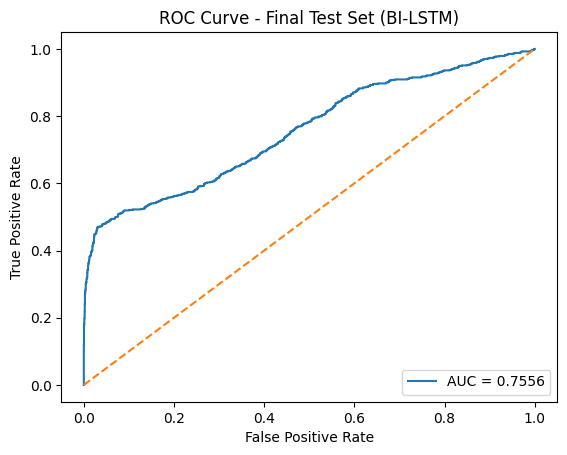

In [5]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION
# =====================================================

import copy
import json

with open(r"C:\SKRIPSI BRYAN\Tahap 1\hyperparameters_bilstm_loss.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)


epochs=20
patience=5
best_recall=0
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val Recall)")

for epoch in range(epochs):

    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    model.eval()

    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)

            outputs=model(X_batch)

            probs=torch.sigmoid(outputs)

            preds = (probs >= 0.5).cpu().numpy().reshape(-1)

            val_preds.extend(preds.tolist())

            val_true.extend(y_batch.numpy().reshape(-1).tolist())

    val_recall=recall_score(val_true,val_preds,pos_label=1)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation Recall: {val_recall:.4f}")

    if val_recall>best_recall:

        best_recall=val_recall
        counter=0
        best_model_state=copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter+=1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter>=patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()

**loss**

In [ ]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION
# =====================================================

import copy
import json

with open("hyperparameters_bilstm.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)


epochs=20
patience=5
best_val_loss=float("inf")
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val Loss)")

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    # ================= VALIDATION =================
    model.eval()

    val_loss=0
    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)
            y_batch=y_batch.to(device)

            outputs=model(X_batch)

            loss=criterion(outputs,y_batch)
            val_loss+=loss.item()

            probs=torch.sigmoid(outputs)

            preds=(probs>=0.5).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.cpu().numpy())

    val_loss=val_loss/len(val_loader)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter=0
        best_model_state=copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter+=1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter>=patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()

**f1**

In [ ]:
# =====================================================
# CELL 3 — FINAL TRAINING + EVALUATION (EARLY STOPPING F1)
# =====================================================

import copy
import json

with open("hyperparameters_bilstm.json") as f:
    params=json.load(f)

print("Using hyperparameters:",params)

batch_size=params["batch_size"]
lr=params["lr"]
hidden_dim=params["hidden_dim"]
dropout=params["dropout"]

train_loader=DataLoader(TextDataset(X_train_pad,y_train),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TextDataset(X_val_pad,y_val),batch_size=batch_size)
test_loader=DataLoader(TextDataset(X_test_pad,y_test),batch_size=batch_size)


class BiLSTM(nn.Module):

    def __init__(self):

        super(BiLSTM,self).__init__()

        self.embedding=nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze=True
        )

        self.lstm=nn.LSTM(
        embedding_dim,
        hidden_dim,
        batch_first=True,
        bidirectional=True
        )

        self.dropout=nn.Dropout(dropout)

        self.fc=nn.Linear(hidden_dim*2,1)

    def forward(self,x):

        x=self.embedding(x)

        _,(hidden,_)=self.lstm(x)

        hidden=torch.cat((hidden[0],hidden[1]),dim=1)

        hidden=self.dropout(hidden)

        out=self.fc(hidden)

        return out.squeeze()


model=BiLSTM().to(device)

criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)

epochs=20
patience=5
best_f1=0
counter=0
best_model_state=None

print("🚀 Training dengan Early Stopping (monitor = Val F1)")

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss=0

    train_loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} - Training",leave=False)

    for X_batch,y_batch in train_loop:

        X_batch,y_batch=X_batch.to(device),y_batch.to(device)

        optimizer.zero_grad()

        outputs=model(X_batch)

        loss=criterion(outputs,y_batch)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        train_loop.set_postfix(loss=loss.item())

    # ================= VALIDATION =================
    model.eval()

    val_preds=[]
    val_true=[]

    val_loop=tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} - Validation",leave=False)

    with torch.no_grad():

        for X_batch,y_batch in val_loop:

            X_batch=X_batch.to(device)

            outputs=model(X_batch)

            probs=torch.sigmoid(outputs)

            preds=(probs>=0.5).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.numpy())

    val_f1=f1_score(val_true,val_preds)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation F1: {val_f1:.4f}")

    # ================= EARLY STOPPING =================
    if val_f1 > best_f1:

        best_f1 = val_f1
        counter = 0
        best_model_state = copy.deepcopy(model.state_dict())

        print("✅ Model terbaik diperbarui")

    else:

        counter += 1

        print(f"⚠️ Tidak ada peningkatan ({counter}/{patience})")

        if counter >= patience:

            print("🛑 Early stopping triggered")
            break

print("✅ Training selesai")


# ================= EVALUATION =================

model.load_state_dict(best_model_state)
model.eval()

all_preds=[]
all_probs=[]

test_loop=tqdm(test_loader,desc="Testing",leave=False)

with torch.no_grad():

    for X_batch,_ in test_loop:

        X_batch=X_batch.to(device)

        outputs=model(X_batch)

        probs=torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())

        all_preds.extend((probs>=0.5).cpu().numpy())

y_pred=np.array(all_preds)
y_proba=np.array(all_probs)


print("\n=== FINAL TEST EVALUATION ===")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1-score :",f1_score(y_test,y_pred))
print("AUC      :",roc_auc_score(y_test,y_proba))


print("\n=== CLASSIFICATION REPORT ===")

print(classification_report(y_test,y_pred,digits=4))


print("=== CONFUSION MATRIX ===")

print(confusion_matrix(y_test,y_pred))


fpr,tpr,_=roc_curve(y_test,y_proba)

roc_auc=auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")

plt.show()